# FX Exchange Rate Data Pipeline

This notebook fetches daily foreign exchange rates from the [Frankfurter API](https://www.frankfurter.dev/) — a free, open-source API based on data published by the European Central Bank (ECB). All rates are quoted with **EUR as the base currency**.

The pipeline is **incremental**: on first run it downloads all available history back to 1999; on subsequent runs it only fetches data newer than what is already stored.

All raw EUR-based rates (34 currencies) are persisted as-is in two formats:
- **DuckDB** (`forex_data.duckdb`) — fast analytical queries directly from Python
- **CSV** (`forex_data.csv`) — portable flat-file export for Excel, other tools, etc.

Cross-rates (e.g. GBP/CHF) are **derived at plot time** from the stored EUR series — no redundant data is written to disk.

The final cell plots the full history of five key pairs on a single chart:

| Pair | Description | Y-axis |
|------|-------------|--------|
| EUR/USD | Euro / US Dollar | Left |
| EUR/GBP | Euro / British Pound | Left |
| EUR/CHF | Euro / Swiss Franc | Left |
| GBP/CHF | British Pound / Swiss Franc (cross) | Left |
| EUR/JPY | Euro / Japanese Yen | **Right** (different scale) |


In [ ]:
#  if running in colab
!pip install duckdb requests -q

## 1. Imports & Configuration

In [9]:
import requests
import pandas as pd
import duckdb
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

# --- CONFIGURATION ---
DB_NAME    = "forex_data.duckdb"   # DuckDB database file
CSV_NAME   = "forex_data.csv"      # CSV export file
TABLE_NAME = "exchange_rates"      # Table name inside DuckDB

# Frankfurter ECB history starts on this date
DEFAULT_START = "1999-01-01"

# All 34 symbols to request from the API (EUR is implicitly the base)
SYMBOLS = (
    "USD,JPY,GBP,CNY,CHF,AUD,CAD,HKD,SGD,INR,KRW,SEK,MXN,NZD,NOK,"
    "TWD,BRL,ZAR,PLN,DKK,IDR,TRY,THB,ILS,HUF,CZK,CLP,PHP,COP,MYR,"
    "AED,SAR,RON,PEN"
)

## 2. Determine the Date Range to Fetch

Connect to DuckDB and check whether the `exchange_rates` table already exists. If it does, we check that its schema matches the current one. A stale table (e.g. created by an older version of this notebook with only 6 columns) is automatically dropped and rebuilt from scratch.

If the schema is current we only fetch dates *after* the most recent stored row; otherwise we start from the beginning of the ECB data series.

In [2]:
# Open (or create) the DuckDB database file
con = duckdb.connect(DB_NAME)

# Expected number of columns: 'date' + 34 currency symbols
EXPECTED_COLS = 1 + len(SYMBOLS.split(","))   # 35

# Check whether our target table already exists
table_exists = (
    con.execute(
        f"SELECT count(*) FROM information_schema.tables "
        f"WHERE table_name = '{TABLE_NAME}'"
    ).fetchone()[0]
    > 0
)

if table_exists:
    # Check how many columns the existing table has
    actual_cols = con.execute(
        f"SELECT count(*) FROM information_schema.columns "
        f"WHERE table_name = '{TABLE_NAME}'"
    ).fetchone()[0]

    if actual_cols != EXPECTED_COLS:
        # Schema mismatch — old table has fewer columns (e.g. previous 6-pair version).
        # Drop it and rebuild from scratch so the full history is stored correctly.
        print(
            f"Schema mismatch: table has {actual_cols} columns, "
            f"expected {EXPECTED_COLS}. Dropping and rebuilding..."
        )
        con.execute(f"DROP TABLE {TABLE_NAME}")
        table_exists = False   # treat as first run
        start_date = DEFAULT_START
    else:
        # Schema is current — find the latest date so we can resume from the next day
        last_date_res = con.execute(f"SELECT MAX(date) FROM {TABLE_NAME}").fetchone()[0]
        start_date = (
            (last_date_res + timedelta(days=1)).strftime("%Y-%m-%d")
            if last_date_res else DEFAULT_START
        )
else:
    # No table yet — download everything from 1999 onwards
    start_date = DEFAULT_START

# Today is always the upper bound
end_date = datetime.now().strftime("%Y-%m-%d")

print(f"Table exists : {table_exists}")
print(f"Fetch range  : {start_date} -> {end_date}")

Table exists : False
Fetch range  : 1999-01-01 -> 2026-03-16


## 3. Fetch Data from the Frankfurter API

The `{start}..{end}` range endpoint returns a JSON object whose `rates` key maps each trading date to a dict of `currency -> rate`. We store **all columns exactly as returned** — no cross-rate maths at ingestion time.

In [3]:
df_final = None  # will hold new rows if any are fetched

if start_date > end_date:
    print("Database is already up to date — nothing to fetch.")
else:
    print(f"Fetching data from {start_date} to {end_date} ...")

    url    = f"https://api.frankfurter.dev/v1/{start_date}..{end_date}"
    params = {"base": "EUR", "symbols": SYMBOLS}

    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()

        if "rates" in data and data["rates"]:
            # Pivot the nested dict -> DataFrame (dates as rows, currencies as columns)
            df_raw = pd.DataFrame(data["rates"]).T.sort_index()
            df_raw.index = pd.to_datetime(df_raw.index)
            df_raw.index.name = "date"

            # Keep every EUR-based column exactly as returned by the API.
            # Column names are ISO currency codes: USD, JPY, GBP, CHF, ...
            df_final = df_raw.reset_index()

            print(f"Fetched {len(df_final)} new trading day(s) x {df_final.shape[1]-1} currencies.")
            display(df_final.head())
        else:
            print("No new rates found for this date range.")
    else:
        print(f"API Error: {response.status_code} — {response.text}")

Fetching data from 1999-01-01 to 2026-03-16 ...
Fetched 6964 new trading day(s) x 28 currencies.


,date,AUD,CAD,CHF,CZK,DKK,GBP,HKD,HUF,JPY,...,CNY,IDR,MYR,PHP,THB,RON,BRL,MXN,INR,ILS
0,1999-01-04,1.9100,1.8004,1.6168,35.107,7.4501,0.71110,9.1332,251.48,133.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999-01-05,1.8944,1.7965,1.6123,34.917,7.4495,0.71220,9.1341,250.80,130.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1999-01-06,1.8820,1.7711,1.6116,34.850,7.4452,0.70760,9.1010,250.67,131.42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1999-01-07,1.8474,1.7602,1.6165,34.886,7.4431,0.70585,9.0131,250.09,129.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999-01-08,1.8406,1.7643,1.6138,34.938,7.4433,0.70940,9.0302,250.15,130.09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Save / Update DuckDB

On first run (or after a schema rebuild) the table is created from the new DataFrame. On subsequent runs the new rows are appended.

In [4]:
if df_final is not None and len(df_final) > 0:
    if not table_exists:
        # First run (or post-migration): create the table schema from the DataFrame
        con.execute(f"CREATE TABLE {TABLE_NAME} AS SELECT * FROM df_final")
        print(f"Created table '{TABLE_NAME}' with {len(df_final)} rows.")
    else:
        # Subsequent runs: insert only the new rows
        con.execute(f"INSERT INTO {TABLE_NAME} SELECT * FROM df_final")
        print(f"Appended {len(df_final)} rows to '{TABLE_NAME}'.")
else:
    print("No new data to write to DuckDB.")

con.close()

Created table 'exchange_rates' with 6964 rows.


## 5. Save / Update CSV

If the CSV exists and its header matches the current schema, new rows are appended. If the CSV is missing or has a stale schema (column count mismatch), it is rewritten from scratch using the full DuckDB table so it stays in sync.

In [5]:
if df_final is not None and len(df_final) > 0:
    csv_exists = os.path.isfile(CSV_NAME)

    # Detect schema mismatch in the CSV by checking its header column count
    csv_schema_ok = False
    if csv_exists:
        csv_header = pd.read_csv(CSV_NAME, nrows=0)
        csv_schema_ok = (len(csv_header.columns) == len(df_final.columns))

    if csv_exists and csv_schema_ok:
        # Schema matches — append new rows without repeating the header
        df_final.to_csv(CSV_NAME, mode="a", header=False, index=False)
        print(f"Appended {len(df_final)} rows to '{CSV_NAME}'.")
    else:
        if csv_exists:
            print("CSV schema mismatch — rebuilding from DuckDB...")
        # Write the full table to CSV so DuckDB and CSV are always in sync
        con2 = duckdb.connect(DB_NAME)
        df_full = con2.execute(f"SELECT * FROM {TABLE_NAME} ORDER BY date").df()
        con2.close()
        df_full.to_csv(CSV_NAME, mode="w", header=True, index=False)
        print(f"Wrote full history ({len(df_full)} rows) to '{CSV_NAME}'.")
else:
    print("No new data to write to CSV.")

Wrote full history (6964 rows) to 'forex_data.csv'.


## 6. Preview Stored Data

Re-open DuckDB and display the most recent rows to confirm everything stored correctly.

In [6]:
# Re-open in read mode
con = duckdb.connect(DB_NAME)

# Pull the 10 most recent trading days
df_preview = con.execute(
    f"SELECT * FROM {TABLE_NAME} ORDER BY date DESC LIMIT 10"
).df()

con.close()

# Show a representative subset of columns to keep the preview readable
preview_cols = ["date", "USD", "JPY", "GBP", "CHF", "AUD", "CAD", "CNY"]
display(df_preview[preview_cols].round(4))

,date,USD,JPY,GBP,CHF,AUD,CAD,CNY
0,2026-03-13,1.1476,182.85,0.8650,0.9034,1.6293,1.5726,7.9145
1,2026-03-12,1.1547,183.43,0.8624,0.9028,1.6190,1.5706,7.9316
2,2026-03-11,1.1581,183.63,0.8636,0.9031,1.6195,1.5742,7.9518
3,2026-03-10,1.1641,183.67,0.8654,0.9027,1.6355,1.5777,8.0057
4,2026-03-09,1.1555,183.15,0.8653,0.9008,1.6465,1.5680,7.9929
5,2026-03-06,1.1561,182.57,0.8669,0.9045,1.6501,1.5782,7.9825
6,2026-03-05,1.1618,183.03,0.8695,0.9064,1.6490,1.5828,8.0177
7,2026-03-04,1.1649,183.02,0.8705,0.9082,1.6503,1.5910,8.0347
8,2026-03-03,1.1606,182.98,0.8717,0.9107,1.6534,1.5883,8.0170
9,2026-03-02,1.1698,184.19,0.8739,0.9117,1.6579,1.5991,8.0512


## 7. Plot Key Pairs — Full History

All five pairs are derived on the fly from the stored EUR-based columns:

- **EUR/USD, EUR/GBP, EUR/CHF, GBP/CHF** share the **left y-axis** (roughly 0.5–2.0 range)
- **EUR/JPY** uses a dedicated **right y-axis** because yen rates (80–170) live on a completely different scale

GBP/CHF is a **cross rate** computed as `EUR/CHF ÷ EUR/GBP`.

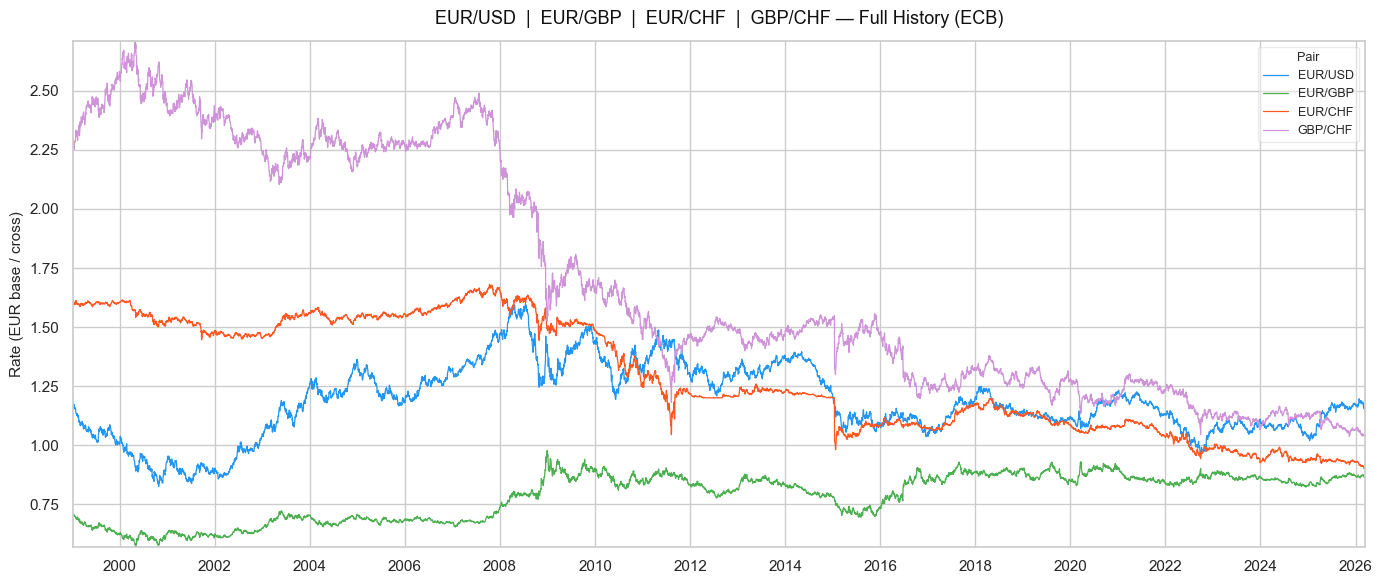

In [15]:
# --- Load the full history from DuckDB ---
con = duckdb.connect(DB_NAME)
df = con.execute(
    f"SELECT date, USD, GBP, CHF FROM {TABLE_NAME} ORDER BY date"
).df()
con.close()

df["date"] = pd.to_datetime(df["date"])

# --- Derive the four pairs from raw EUR-based columns ---
df["EUR/USD"] = df["USD"]
df["EUR/GBP"] = df["GBP"]
df["EUR/CHF"] = df["CHF"]
df["GBP/CHF"] = df["CHF"] / df["GBP"]   # cross rate

# Melt to long format — required for Seaborn's hue grouping:
# wide: one column per pair  ->  long: one row per (date, pair, rate) observation
df_long = df[["date", "EUR/USD", "EUR/GBP", "EUR/CHF", "GBP/CHF"]].melt(
    id_vars="date", var_name="Pair", value_name="Rate"
)

# --- Seaborn plot ---
sns.set_theme(style="whitegrid")

# , rc={"axes.facecolor": "#0f0f0f", "figure.facecolor": "#1a1a1a",
#                                     "grid.color": "#2a2a2a", "text.color": "#e0e0e0",
#                                     "axes.labelcolor": "#e0e0e0", "xtick.color": "#e0e0e0",
#                                     "ytick.color": "#e0e0e0", "axes.edgecolor": "#333333"})



# Four visually distinct colours
PALETTE = {
    "EUR/USD": "#2196F3",   # blue
    "EUR/GBP": "#4CAF50",   # green
    "EUR/CHF": "#FF5722",   # deep orange
    "GBP/CHF": "#CE93D8",   # light purple
}

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=df_long,
    x="date",
    y="Rate",
    hue="Pair",
    palette=PALETTE,
    linewidth=0.9,
    ax=ax,
)

# X-axis: one tick every 2 years, rotated for readability
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.xaxis.get_majorticklabels(),  ha="center")


ax.margins(x=0, y=0)
ax.set_xlabel('')
ax.set_ylabel("Rate (EUR base / cross)", fontsize=11)
ax.legend(title="Pair", fontsize=9, title_fontsize=9, framealpha=0.4)

plt.title(
    "EUR/USD  |  EUR/GBP  |  EUR/CHF  |  GBP/CHF — Full History (ECB)",
    fontsize=13, pad=12, color="#101010"
)
plt.tight_layout()
plt.show()
